In [77]:
import numpy as np
import pandas as pd
import random as random
import matplotlib.pyplot as plt
from scipy.special import gammaln

In [61]:
from mpl_toolkits.mplot3d import Axes3D

In [48]:
#Modelos de la dependencia P(Y=1 | x)

#Logístico
alpha1 = -5
beta1 = 2
def logist(x,alpha = alpha1, beta=beta1):
    e = np.exp(alpha + beta*x)
    return e/(1+e)

#Log-log complementario
alpha2 = -2
beta2 = 2

def log_com(x, alpha = alpha2, beta = beta2):
    return 1 - np.exp(-np.exp(alpha + beta*x))

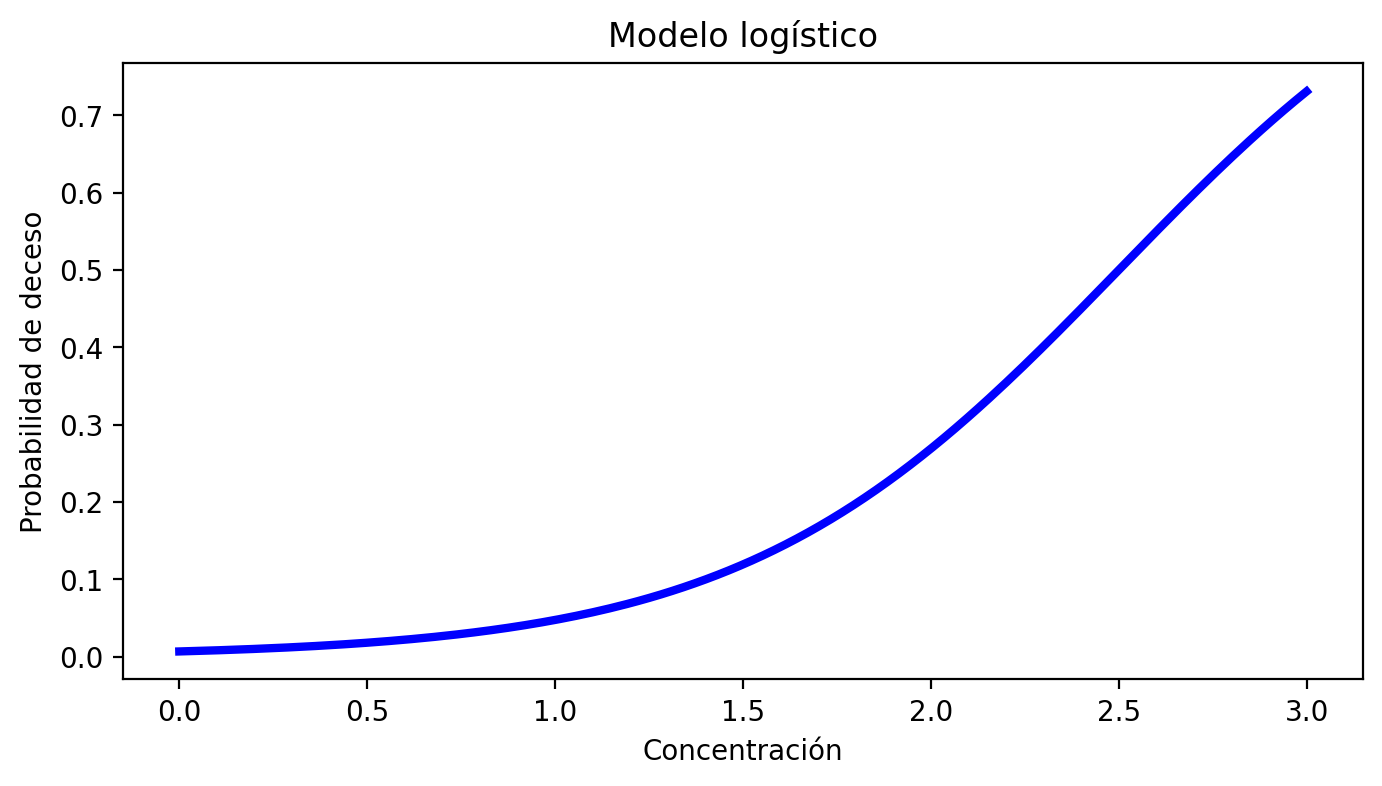

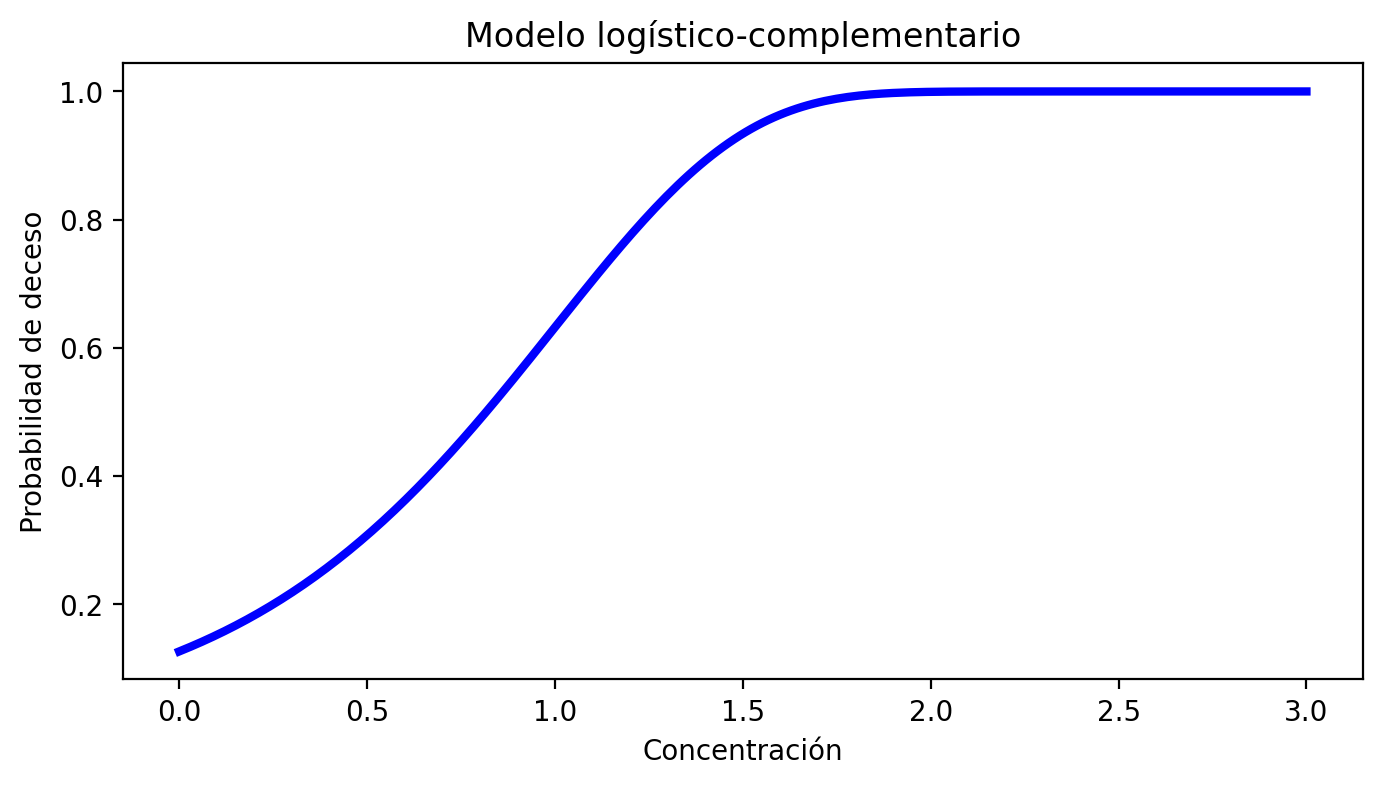

In [49]:
#Gráfico de los modelos de dependencia
x = np.linspace(0, 3, 200)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(x, logist(x), color ="blue", linewidth = 3)
ax.set_title("Modelo logístico")
ax.set_xlabel("Concentración")
ax.set_ylabel("Probabilidad de deceso")
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(x, log_com(x), color ="blue", linewidth = 3)
ax.set_title("Modelo logístico-complementario")
ax.set_xlabel("Concentración")
ax.set_ylabel("Probabilidad de deceso")
plt.show()

##Función de verosimilitud

Las funciones $\tilde \pi, \bar \pi $ son de la forma $ \mathbb{P}(Y=1 | x)$, queremos inferir la forma de las funciones dados los resultados de los experimentos, es decir, cual es la mejor manera de modelar la probabilidad de deceso dada una concentración. La forma de cada función esta determinada por los parámetros $\alpha$ y $\beta$, m'as aún, para cualquieras sean los valores reales de $\alpha$ y $\beta$ tenemos que $0 \leq \tilde \pi, \bar \pi \leq 1$  por lo que el espacio donde buscamos los parámetros es $\mathbb R ^2$. 

Si $Y$ es la variable aleatoria indicatriz de deceso de un escarabajo bajo la concentración $x$, vemos que $Y$ es una Bernoulli de parámetro $\pi(x)$. Como los datos vienen agrupados consideramos el $i$-ésimo experimento como la suma de la v.a. que representa cada escarabajo. Por lo que podemos definir: $Z_i$ la cantidad de decesos de $n_i$ escarabajos expuestos a la concentración $x_i$ que distribuye como una Binomial($n_i, \pi(x)$). Es importante notar que la muestra tomada por los experimentos $(Z_i)_{i=1}^8$ son independientes pero no distribuyen de la misma manera.

Con todo lo anterior vemos que, la función general de la verosimilitud $L$ y log-verosimilitud $l$ es de la forma
$$
   L(\alpha,\beta) = \prod_{i=1}^8 \mathbb{P}_{\alpha,\beta}(z_i = k) = \prod_{i=1}^8 \binom{n_i}{z_i}\pi(x)^{z_i}(1-\pi(x))^{n_i - z_i}
$$

$$
l(\alpha,\beta) = \sum_{i=1}^8 (\operatorname{log} (\binom{n_i}{z_i} + {z_i}\operatorname{log}\pi(x)    + (n_i - z_i)\operatorname{log}(1-\pi(x)))
$$


Para las funciones ver. y log-ver asociadas a $\tilde \pi$ y $\bar \pi $ notadas como $\tilde L, \tilde l$ y $\bar L, \bar l$ respectivamente, obtenemos para $\tilde \pi$

$$
\tilde L(\alpha_1, \beta_1) = \prod_{i=1}^k \binom{n_i}{z_i}( \frac{\exp(\alpha_1 + \beta_1 x_i)}{1 + \exp(\alpha_1 + \beta_1 x_i)} )^{z_i}( \frac{1}{1 + \exp(\alpha_1 + \beta_1 x_i)})^{n_i - z_i}
$$
$$
\tilde l(\alpha_1, \beta_1) = \sum_{i=1}^8 ( \operatorname{log}\binom{n_i}{z_i} + z_i (\alpha_1 + \beta_1 x_i) - n_i \operatorname{log}(1 + \exp(\alpha_1 + \beta_1 x_i)))
$$

y para \bar \pi

$$
\bar L(\alpha_2, \beta_2) = \prod_{i=1}^8 \binom{n_i}{z_i} (1 - \exp(-\exp(\alpha_2 + \beta_2 x_i)))^{z_i} (\exp(-\exp(\alpha_2 + \beta_2 x_i)))^{n_i - z_i}
$$

$$
\bar l(\alpha_2, \beta_2) = \sum_{i=1}^8 (\operatorname{log}\binom{n_i}{z_i} + z_i \ln(1 - \exp(-\exp(\alpha_2 + \beta_2 x_i))) - (n_i - z_i) \exp(\alpha_2 + \beta_2 x_i))
$$

In [88]:
##Código de las funciones log-ver para la primera distribución

# Cargar datos
df = pd.read_csv("../data/raw/datos_pesticida.csv")

concentracion = df["concentracion"].to_numpy()
Z = df[" nMuertos"].to_numpy()
N = df[" nExpuestos"].to_numpy()


def l_v(alpha, beta):
    AUX = alpha + beta * concentracion

    log_comb = gammaln(N + 1) - gammaln(Z + 1) - gammaln(N - Z + 1)
    
    coor_gammaln = (gammaln(N + 1) - gammaln(Z + 1) - gammaln(N - Z + 1)) + Z * AUX - N * np.log(1 + np.exp(AUX))

    return np.sum(coor_gammaln)

print(l_v(-60,34))

-23.108989760819256


<Figure size 1280x960 with 0 Axes>

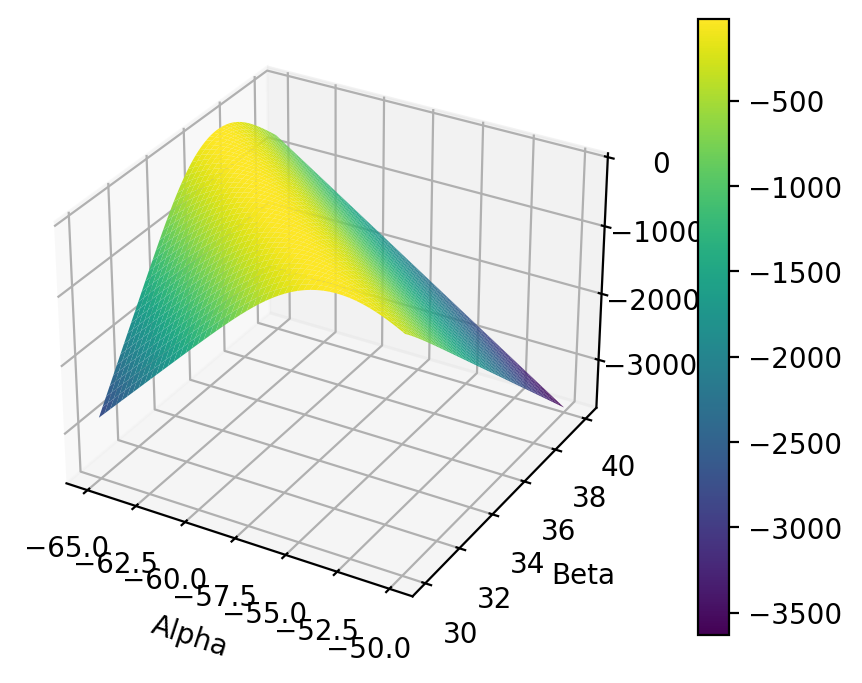

In [82]:
from numpy import meshgrid

fig = plt.figure()
x = np.linspace(-65, -50, 100)
y = np.linspace(30, 40, 100)
ALPHA, BETA = meshgrid(x, y)

l_vR = np.vectorize(l_v)
z = l_vR(ALPHA, BETA)

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(projection="3d")
surf = ax.plot_surface(ALPHA, BETA, z, cmap="viridis")
ax.set_xlabel("Alpha")
ax.set_ylabel("Beta")
ax.set_zlabel("Log-Verosimilitud")
fig.colorbar(surf)

plt.show()